# Market noise — multi-week falsifiers

Joins noise_std to quoted/proxy spreads across venues. Artifact spine: `out/gap_close/` + denser mid-clock in `out/blocker_close/`.


In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # research/

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_ratio_hist.png', 'fig_tob_coverage.png', 'fig_tsrv_oos.png', 'signal_board.png']


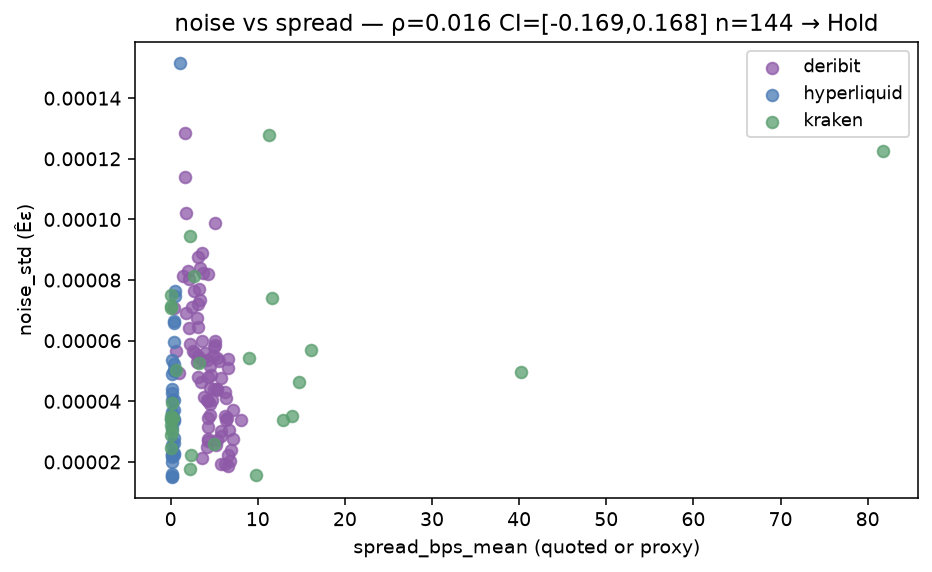

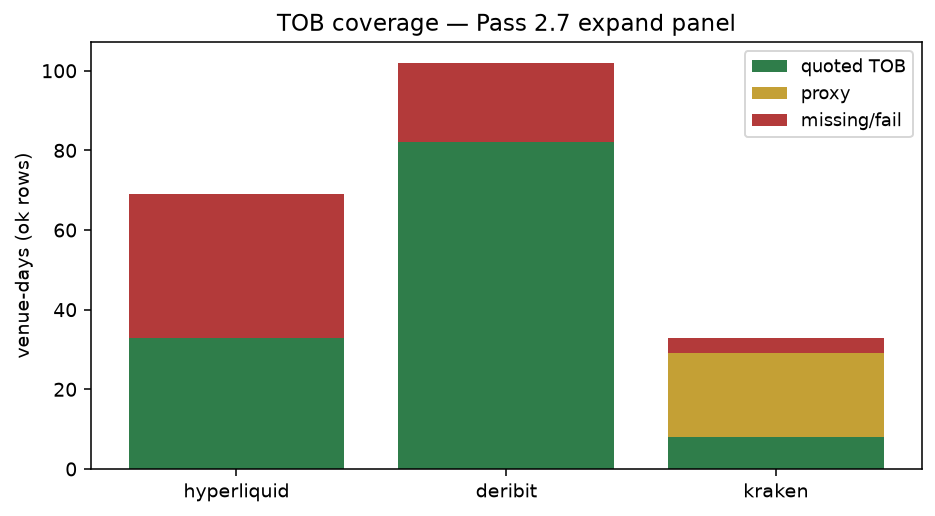

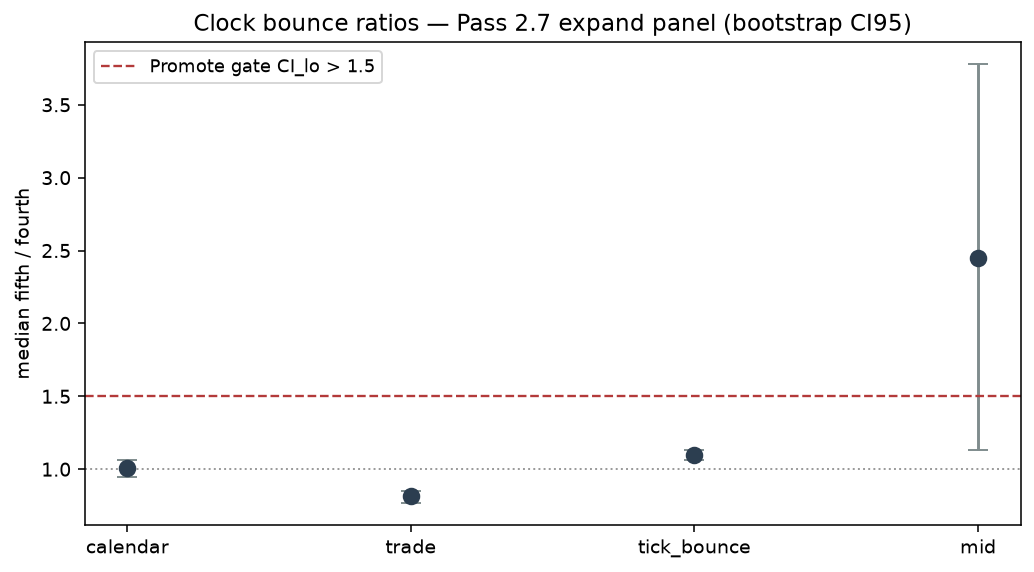

market_noise gate {'decision': 'Hold', 'why': 'ρ=0.829 but falsifier weak (p=0.0725, same_sign=False, n=6)', 'id': 'liq.noise_vs_spread'}
corr {'n_rows': 6, 'spearman_noise_vs_spread': 0.8285714285714286, 'spearman_noise_vs_amihud': 0.3142857142857143, 'spearman_noise_vs_intensity': 0.42857142857142855, 'shuffle': {'n': 400, 'spread_p': 0.0725, 'amihud_p': 0.5675, 'spread_null_p95': 0.8285714285714286, 'amihud_null_p95': 0.8285714285714286}, 'time_split': {'early_days': ['2026-09-28'], 'late_days': ['2026-09-29', '2026-09-30'], 'early_noise_spread': nan, 'late_noise_spread': 0.8, 'early_noise_amihud': nan, 'late_noise_amihud': 0.0}}

=== liq.noise_vs_spread ===
rho {'n': 144.0, 'rho': 0.016405433646812958, 'lo': -0.1693348605417571, 'hi': 0.16769039868177793}
shuffle_p 0.8375 block_p 0.74625
time_split early/late {'n': 59.0, 'rho': -0.2945061367621274, 'lo': -0.2696332554061952, 'hi': 0.23496201052016363} {'n': 85.0, 'rho': 0.22202462380300958, 'lo': -0.2085123119015048, 'hi': 0.237008

In [2]:
show_fig('fig_noise_vs_spread.png')
show_fig('fig_tob_coverage.png')
show_fig('fig_clock_medians.png')

mn = jload('market_noise/market_noise.json')
print('market_noise gate', mn.get('gate'))
print('corr', mn.get('corr'))

sf = gc['spread_falsify']
print('\n=== liq.noise_vs_spread ===')
print('rho', sf['rho_spread'])
print('shuffle_p', sf['shuffle_p'], 'block_p', sf['block_shuffle_p'])
print('time_split early/late', sf['time_split']['early'], sf['time_split']['late'])
print('decision', sf['gate'])

print('\n=== mid-clock blocker ===')
print(bc['mid_clock']['gate'])
print('coverage', bc['mid_clock']['mid_coverage_by_venue'])
print('\n', (BOOK/'chapters/market_noise/EXP_REPORT.md').read_text())


### Kraken TOB status

- Spot L2 from S3 is **quoted** (not invented).  
- Futures historical L2 **absent** in sealed archives — proxies only for history; live REST ingest for forward TOB.  
- Do not Promote liquidity claims that depend on futures quoted spreads until the md plane captures book.
